# Week 39, Monday lecture: stochastic gradient descent once more, logistic regression, and the simple perceptron

**FYS-STK3155/4155, Monday September 21, 2026**

This notebook contains the code behind every figure and number in the Monday
slides (`week39slides.pdf`). It follows the lecture: a twenty-minute reminder
of stochastic gradient descent (Section 4.7 of the lecture notes), logistic
regression (Chapter 5, Sections 5.1–5.7 and 5.9, with a closer look at what
Adam can and cannot do about features that are not standardised), and finally
logistic regression drawn as a single neuron, the simple perceptron
(Section 5.8.1). The same picture read backwards — automatic differentiation,
Section 5.8.2 — is taken up in week 40 together with neural networks. The
functions are the ones
in `make_week39_figures.py`; the seed is 2026 so that the figures here are the
figures on the slides.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"
GREEN = "#228833"
np.set_printoptions(precision=4, suppress=True)

## Part 1: stochastic gradient descent once more (Section 4.7)

Every cost in this course is a sum over data points, Eq. (4.32), so the
gradient is a sum, and a random *minibatch* $B$ of $M$ points gives an
unbiased estimate of it at $M/n$ of the price, Eqs. (4.33)–(4.35). One pass
through the $n/M$ minibatches is an *epoch*, and by the flop count of
Eq. (4.36) an epoch of SGD costs exactly one step of gradient descent. The
book's Figure 4.5 (least squares, $n=10^5$, $p=20$, $\kappa=213$) shows what
that buys per flop: gradient descent needs 640 steps to reach the statistical
floor $\sigma^2 p/n$, SGD with $M=32$ and a decaying learning rate about five
epochs.

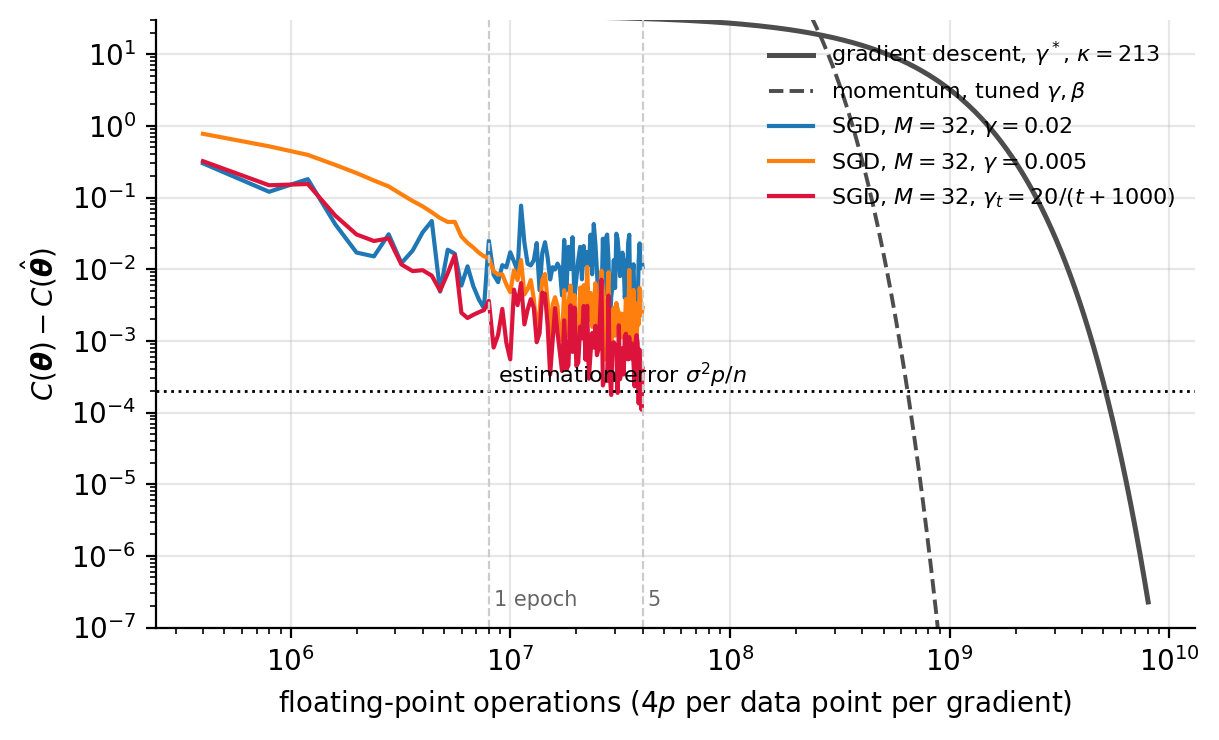

In [2]:
Image("../BookFigures/chapter04_optimization/sgd_vs_gd.png", width=620)

At a constant learning rate the iterate does not converge but *equilibrates*
in a cloud of radius $\propto\sqrt{\gamma/M}$ around the minimum,
Eq. (4.39); only a decaying $\gamma_t$, Eq. (4.40), removes it. The loop below
is the one you write for part h) of Project 1, and the structure every
experiment in this notebook follows: the optimiser knows nothing about the
data, the data loop knows nothing about the optimiser, and the gradient is
one function that is handed either all rows or a minibatch of them.

In [3]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; the step function of Section 4.12."""
    if method == "plain":                                                       # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                                    # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + gamma * g
        return theta - v, state
    if method == "adagrad":                                                     # Eqs. (4.42), (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                                     # Eqs. (4.47), (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                                        # Eqs. (4.51)-(4.55)
        state["m"] = m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")


def make_batches(n, M, rng):
    """Shuffle the indices once per epoch and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[k:k + M] for k in range(0, n, M)]


def train(gradient, X, y, method="plain", gamma=0.1, M=None, n_epochs=10,
          t0=None, seed=2026, record=None):
    """The minibatch loop of Eq. (5.45); M=None is full-batch gradient descent.
    gamma_t = gamma*t0/(t+t0) when t0 is given (a schedule of the type of Eq. 4.40).
    record(theta) is called after every epoch and its values are returned."""
    n, p = X.shape
    M = n if M is None else M
    rng = np.random.default_rng(seed)
    theta, state, t, out = np.zeros(p), {}, 0, []
    for epoch in range(n_epochs):
        for b in make_batches(n, M, rng):
            t += 1
            gam = gamma if t0 is None else gamma * t0 / (t + t0)
            theta, state = optimiser_step(method, theta, gradient(theta, X[b], y[b]), state, t, gam)
        if record is not None:
            out.append(record(theta))
    return theta, out

## Part 2: logistic regression (Chapter 5)

### Classification, and why not a straight line (Section 5.1)

The responses are $y_i\in\{0,1\}$: whether a person has had coronary heart
disease (CHD), against age, for $n=100$ persons. Least squares on the labels,
Eq. (5.2), gives a line that is negative for the young and above one for the
old, and a single distant point moves its threshold. What is meaningful is
the mean within each age group: confined to $[0,1]$ and S-shaped. The logistic
function, Eq. (5.3), is that S-shape,

$$
\sigma(t)=\frac{1}{1+e^{-t}},\qquad 1-\sigma(t)=\sigma(-t),\qquad
\sigma'(t)=\sigma(t)\bigl(1-\sigma(t)\bigr)\le\tfrac14,
$$

and the model, Eq. (5.10), makes the *log-odds* linear in the features:

$$
p(y_i=1\mid x_i)=\sigma(\theta_0+\theta_1 x_i),\qquad
\ln\frac{p}{1-p}=\theta_0+\theta_1 x_i .
$$

The cross entropy, Eqs. (5.13)–(5.14), is the negative log-likelihood of the
Bernoulli trials; its gradient and Hessian, Eqs. (5.17) and (5.19), are

$$
\nabla C=\boldsymbol{X}^T(\boldsymbol{p}-\boldsymbol{y}),\qquad
\boldsymbol{H}=\boldsymbol{X}^T\boldsymbol{W}\boldsymbol{X},\quad
W_{ii}=p_i(1-p_i),
$$

and $\boldsymbol{H}$ is positive semi-definite, so the problem is convex.
Below, all three carry the $1/n$ convention of the book's class.

In [6]:
def load_chd(path="../../LectureNotes/DataFiles/chddata.csv"):
    """Columns: ID, age, age group (1-8), CHD (0/1); n = 100 persons."""
    data = np.loadtxt(path, delimiter=",")
    age, group, chd = data[:, 1], data[:, 2].astype(int), data[:, 3]
    return age, group, chd


def sigmoid(t):
    """The logistic function, Eq. (5.3), in its numerically stable form."""
    a = np.exp(-np.abs(t))
    return np.where(t >= 0, 1.0 / (1.0 + a), a / (1.0 + a))


def cross_entropy(theta, X, y):
    """Mean cross entropy, Eq. (5.14) divided by n."""
    z = X @ theta
    return np.mean(np.logaddexp(0.0, z) - y * z)


def gradient(theta, X, y):
    """Eq. (5.17) divided by n: X^T (p - y) / n."""
    return X.T @ (sigmoid(X @ theta) - y) / len(y)


def hessian(theta, X, y):
    """Eq. (5.19) divided by n: X^T W X / n with W = diag(p(1-p))."""
    p = sigmoid(X @ theta)
    return X.T @ ((p * (1.0 - p))[:, None] * X) / len(y)


def newton(X, y, n_iter=25, tol=1e-12):
    """Newton-Raphson / IRLS, Eq. (5.33); returns every iterate."""
    theta = np.zeros(X.shape[1])
    path = [theta.copy()]
    for _ in range(n_iter):
        step = np.linalg.solve(hessian(theta, X, y), gradient(theta, X, y))
        theta = theta - step
        path.append(theta.copy())
        if np.linalg.norm(step) < tol:
            break
    return np.array(path)


def gradient_descent(X, y, gamma, n_iter):
    """Plain gradient descent, Eq. (5.31) with the 1/n convention; every iterate."""
    theta = np.zeros(X.shape[1])
    path = [theta.copy()]
    for _ in range(n_iter):
        theta = theta - gamma * gradient(theta, X, y)
        path.append(theta.copy())
    return np.array(path)


def sgd(X, y, gamma, M, n_epochs, t0=None, seed=2026):
    """Minibatch SGD, Eq. (5.45); gamma_t = gamma*t0/(t+t0) when t0 is given."""
    rng = np.random.default_rng(seed)
    n = len(y)
    theta = np.zeros(X.shape[1])
    path = [theta.copy()]
    t = 0
    for _ in range(n_epochs):
        idx = rng.permutation(n)
        for k in range(0, n, M):
            t += 1
            b = idx[k:k + M]
            gam = gamma if t0 is None else gamma * t0 / (t + t0)
            theta = theta - gam * gradient(theta, X[b], y[b])
            path.append(theta.copy())
    return np.array(path)


def chd_design(age):
    """Design matrix [1, standardised age]; standardising keeps kappa small."""
    mu, sd = age.mean(), age.std()
    return np.column_stack([np.ones_like(age), (age - mu) / sd]), mu, sd


In [7]:
age, group, chd = load_chd()
X, mu, sd = chd_design(age)
path = newton(X, chd)
theta = path[-1]
print(f"n = {len(age)}, {int(chd.sum())} with CHD; age mean {mu:.1f}, sd {sd:.1f}")
print(f"Newton-Raphson: {len(path) - 1} iterations, theta (standardised age) = {theta}")
print(f"in years: log-odds = {theta[0] - theta[1]*mu/sd:.3f} + {theta[1]/sd:.4f} * age")
print(f"odds ratio per 10 years: exp(10 * {theta[1]/sd:.4f}) = {np.exp(10*theta[1]/sd):.2f}")
print(f"p = 1/2 at age {mu - sd*theta[0]/theta[1]:.1f}")
print(f"C(theta_hat) = {cross_entropy(theta, X, chd):.5f}, training accuracy {np.mean((X @ theta > 0) == chd):.2f}")

n = 100, 43 with CHD; age mean 44.5, sd 12.0
Newton-Raphson: 6 iterations, theta (standardised age) = [-0.3665  1.2034]
in years: log-odds = -4.842 + 0.1006 * age
odds ratio per 10 years: exp(10 * 0.1006) = 2.74
p = 1/2 at age 48.1
C(theta_hat) = 0.55147, training accuracy 0.75


straight line: CHD = -0.473 + 0.0203 age -> negative below age 23, above one at 73


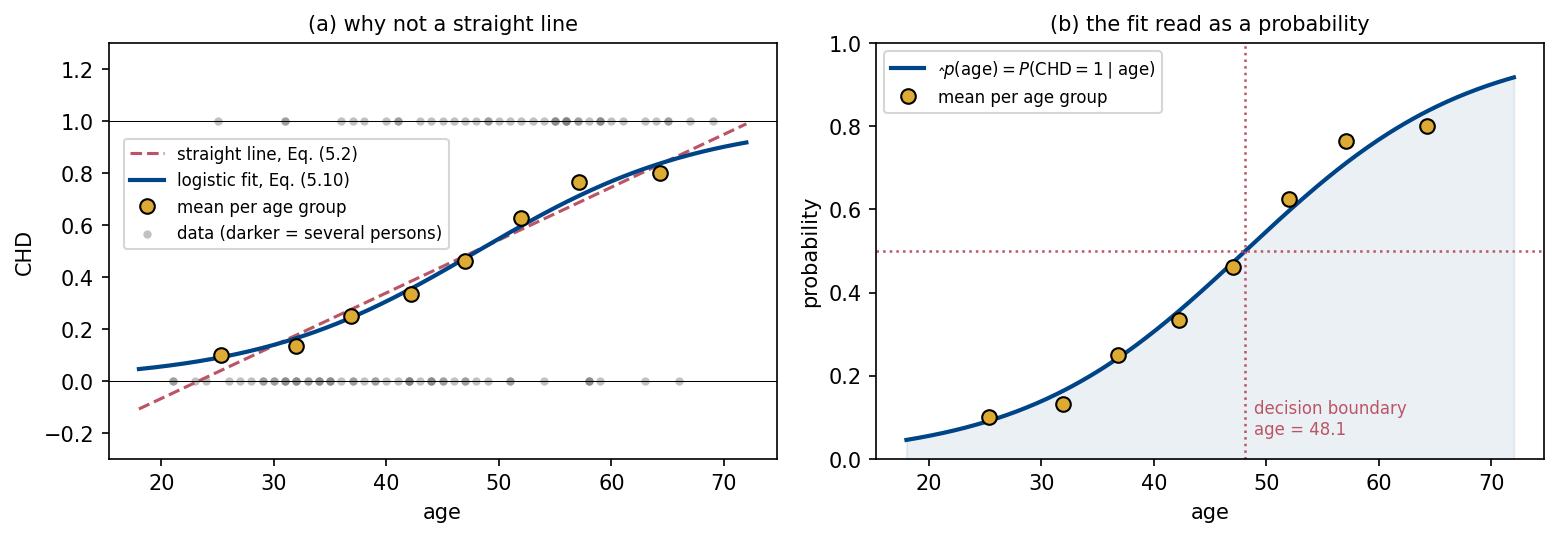

In [8]:
def figure_chd_fit(age, group, chd, theta, mu, sd, fname="week39_chd_fit.pdf"):
    grid = np.linspace(18, 72, 300)
    Xg = np.column_stack([np.ones_like(grid), (grid - mu) / sd])
    # the straight-line attempt of Eq. (5.2): OLS on the 0/1 labels
    Xa = np.column_stack([np.ones_like(age), age])
    beta = np.linalg.lstsq(Xa, chd, rcond=None)[0]
    means = np.array([chd[group == g].mean() for g in range(1, 9)])
    ages = np.array([age[group == g].mean() for g in range(1, 9)])
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
    ax = axes[0]
    ax.scatter(age, chd, s=16, color=GREY, alpha=0.45, linewidths=0,
               label="data (darker = several persons)")
    ax.plot(grid, beta[0] + beta[1] * grid, "--", color=RED, label="straight line, Eq. (5.2)")
    ax.plot(grid, sigmoid(Xg @ theta), color=BLUE, lw=2, label="logistic fit, Eq. (5.10)")
    ax.plot(ages, means, "o", color=YELLOW, ms=7, mec="k", label="mean per age group")
    ax.axhline(0, color="k", lw=0.5); ax.axhline(1, color="k", lw=0.5)
    ax.set_xlabel("age"); ax.set_ylabel("CHD"); ax.set_ylim(-0.3, 1.3)
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(0.01, 0.79))
    ax.set_title("(a) why not a straight line", fontsize=10)
    ax = axes[1]
    p = sigmoid(Xg @ theta)
    ax.plot(grid, p, color=BLUE, lw=2, label=r"$\hat p(\mathrm{age})=P(\mathrm{CHD}=1\mid\mathrm{age})$")
    ax.fill_between(grid, 0, p, color=BLUE, alpha=0.08)
    age50 = mu - sd * theta[0] / theta[1]
    ax.axvline(age50, color=RED, ls=":", lw=1.2)
    ax.axhline(0.5, color=RED, ls=":", lw=1.2)
    ax.text(age50 + 0.8, 0.06, f"decision boundary\nage = {age50:.1f}", fontsize=8, color=RED)
    ax.plot(ages, means, "o", color=YELLOW, ms=7, mec="k", label="mean per age group")
    ax.set_xlabel("age"); ax.set_ylabel("probability"); ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="upper left")
    ax.set_title("(b) the fit read as a probability", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname, bbox_inches="tight")
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    return beta, age50


beta, age50 = figure_chd_fit(age, group, chd, theta, mu, sd)
print(f"straight line: CHD = {beta[0]:.3f} + {beta[1]:.4f} age -> negative below age {-beta[0]/beta[1]:.0f}, above one at {(1-beta[0])/beta[1]:.0f}")
Image("week39_chd_fit.png", width=900)

The data are plotted where they are, at $0$ and $1$, without jitter; a darker
point is several persons of the same age. A unit increase in age multiplies
the odds of CHD by $e^{0.1006}$, a decade
by $e^{1.006}=2.7$: every coefficient of a logistic regression is an odds
ratio, which is why it is the classifier of medicine and economics. The
probability crosses one half where the log-odds vanish, at 48 years — the
decision boundary. With the age standardised the parameters change
($\boldsymbol{\theta}=(-0.37, 1.20)$), the model does not.

### Optimising the cross entropy: gradient descent against Newton (Section 5.7)

Gradient descent, Eq. (5.31), needs a learning rate. The Hessian changes along
the path, but at $\boldsymbol{\theta}=0$ every $W_{ii}=1/4$ exactly, so the
stability bound, Eq. (5.46), is
$\gamma<8/\lambda_{\max}(\boldsymbol{X}^T\boldsymbol{X}/n)$ — with the age
standardised, $\boldsymbol{X}^T\boldsymbol{X}/n=\boldsymbol{I}$ and
$\gamma_{\max}=8$. Newton–Raphson, Eq. (5.33), is iteratively reweighted least
squares, Eq. (5.34): a weighted linear regression with the weights recomputed
at every pass.

lambda_max(X^T X/n) = 1.000 -> gamma_max = 8.0; kappa(H) at the optimum = 1.50
gradient descent at gamma = 1: excess cost after 1/5/20/50 steps = 8.6e-02 / 1.6e-02 / 1.5e-04 / 3.3e-08 ; first below 1e-4 at step 22
Newton: 6 steps to machine precision
minibatch cloud at theta = 0: |grad C| = 0.253, rms spread M=5: 0.286, M=25: 0.120 (ratio 2.38, sqrt(5) = 2.24)
SGD, M=5 (20 updates per epoch), 30 epochs: mean excess over the last 20 updates, constant gamma = 1: 1.4e-02, decaying gamma_t = 50/(t+50): 8.5e-05


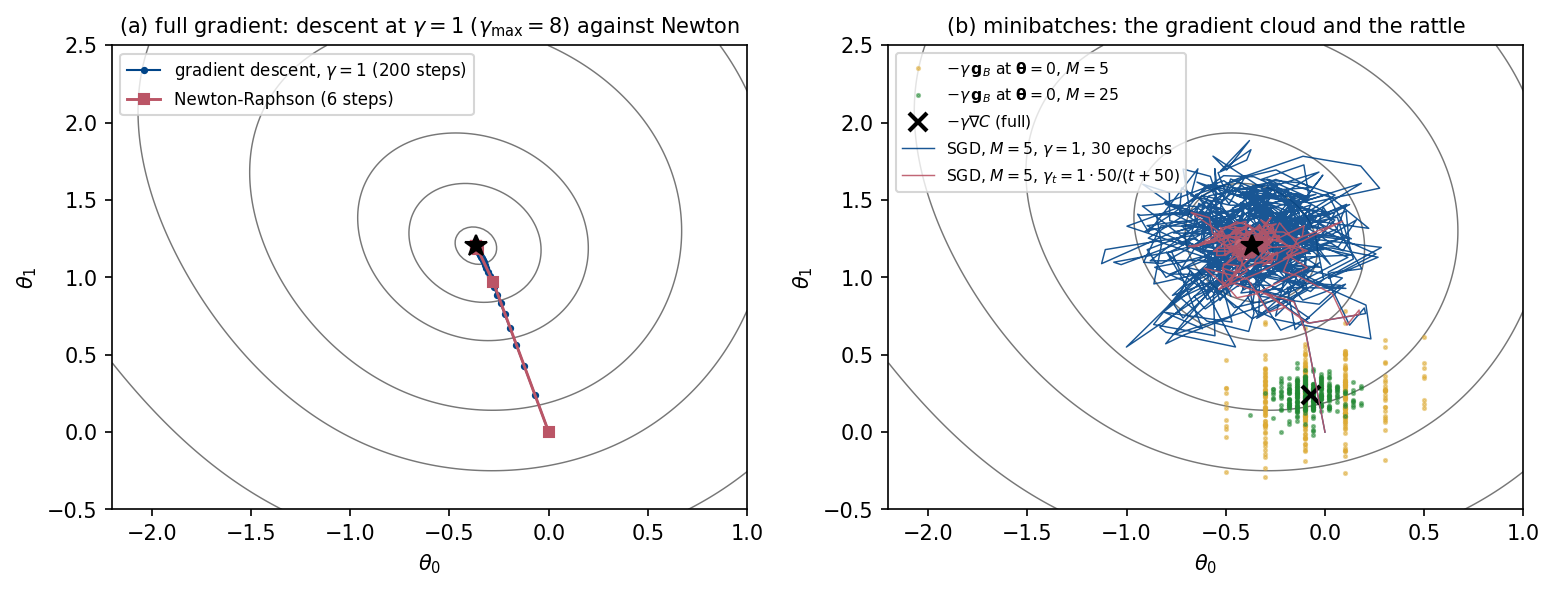

In [9]:
def figure_paths(X, y, gamma=1.0, fname="week39_logreg_paths.pdf"):
    path_newton = newton(X, y)
    theta_hat = path_newton[-1]
    c_hat = cross_entropy(theta_hat, X, y)
    lam_max = np.linalg.eigvalsh(X.T @ X / len(y)).max()
    gamma_safe = 8.0 / lam_max                           # Eq. (5.46); gamma below it
    path_gd = gradient_descent(X, y, gamma, 200)
    ev = np.linalg.eigvalsh(hessian(theta_hat, X, y))
    # contours
    t0 = np.linspace(-2.2, 1.0, 160); t1 = np.linspace(-0.5, 2.5, 160)
    T0, T1 = np.meshgrid(t0, t1)
    C = np.array([[cross_entropy(np.array([a, b]), X, y) for a in t0] for b in t1])
    levels = c_hat + np.array([1e-3, 1e-2, 3e-2, 0.1, 0.2, 0.4, 0.7])

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.1))
    for ax in axes:
        ax.contour(T0, T1, C, levels=levels, colors=GREY, linewidths=0.7)
        ax.plot(*theta_hat, "*", color="k", ms=11, zorder=5)
        ax.set_xlabel(r"$\theta_0$"); ax.set_ylabel(r"$\theta_1$")
    ax = axes[0]
    ax.plot(path_gd[:, 0], path_gd[:, 1], "-o", color=BLUE, ms=2.5, lw=1,
            label=rf"gradient descent, $\gamma={gamma:g}$ (200 steps)")
    ax.plot(path_newton[:, 0], path_newton[:, 1], "-s", color=RED, ms=5, lw=1.4,
            label=f"Newton-Raphson ({len(path_newton) - 1} steps)")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_title(rf"(a) full gradient: descent at $\gamma={gamma:g}$ ($\gamma_{{\max}}={gamma_safe:g}$) against Newton", fontsize=10)
    # (b) SGD: the cloud at theta = 0, then the paths
    ax = axes[1]
    rng = np.random.default_rng(2026)
    g_full = gradient(np.zeros(2), X, y)
    spread = {}
    for M, col in ((5, YELLOW), (25, GREEN)):
        cloud = np.array([gradient(np.zeros(2), X[b], y[b])
                          for b in (rng.choice(len(y), M, replace=False) for _ in range(300))])
        spread[M] = np.sqrt(np.mean(np.sum((cloud - g_full) ** 2, axis=1)))
        ax.plot(-cloud[:, 0] * gamma, -cloud[:, 1] * gamma, ".", color=col, ms=3, alpha=0.5,
                label=rf"$-\gamma\,\mathbf{{g}}_B$ at $\mathbf{{\theta}}=0$, $M={M}$")
    ax.plot(-g_full[0] * gamma, -g_full[1] * gamma, "x", color="k", ms=9, mew=2,
            label=r"$-\gamma\nabla C$ (full)")
    p_const = sgd(X, y, gamma=gamma, M=5, n_epochs=30)
    p_decay = sgd(X, y, gamma=gamma, M=5, n_epochs=30, t0=50.0)
    ax.plot(p_const[:, 0], p_const[:, 1], "-", color=BLUE, lw=0.7, alpha=0.9,
            label=rf"SGD, $M=5$, $\gamma={gamma:g}$, 30 epochs")
    ax.plot(p_decay[:, 0], p_decay[:, 1], "-", color=RED, lw=0.7, alpha=0.9,
            label=rf"SGD, $M=5$, $\gamma_t={gamma:g}\cdot50/(t+50)$")
    ax.legend(fontsize=7.5, loc="upper left")
    ax.set_title("(b) minibatches: the gradient cloud and the rattle", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname, bbox_inches="tight")
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    # numbers for the slides
    ex_gd = cross_entropy(path_gd[-1], X, y) - c_hat
    ex_c = np.array([cross_entropy(th, X, y) - c_hat for th in p_const[-20:]])
    ex_d = np.array([cross_entropy(th, X, y) - c_hat for th in p_decay[-20:]])
    first_below = next(k for k, th in enumerate(path_gd) if cross_entropy(th, X, y) - c_hat < 1e-4)
    return dict(theta_hat=theta_hat, c_hat=c_hat, lam_max=lam_max, gamma_safe=gamma_safe, gamma=gamma,
                kappa=ev.max() / ev.min(), n_newton=len(path_newton) - 1,
                gd_excess_200=ex_gd, gd_first_below_1e4=first_below,
                gd_excess_at=[cross_entropy(path_gd[k], X, y) - c_hat for k in (1, 5, 20, 50)],
                spread=spread, gnorm=np.linalg.norm(g_full),
                sgd_const_excess=ex_c.mean(), sgd_decay_excess=ex_d.mean(),
                updates_per_epoch=int(np.ceil(len(y) / 5)))


out = figure_paths(X, chd, gamma=1.0)
print(f"lambda_max(X^T X/n) = {out['lam_max']:.3f} -> gamma_max = {out['gamma_safe']:.1f}; kappa(H) at the optimum = {out['kappa']:.2f}")
print("gradient descent at gamma = 1: excess cost after 1/5/20/50 steps =",
      " / ".join(f"{v:.1e}" for v in out["gd_excess_at"]),
      f"; first below 1e-4 at step {out['gd_first_below_1e4']}")
print(f"Newton: {out['n_newton']} steps to machine precision")
print(f"minibatch cloud at theta = 0: |grad C| = {out['gnorm']:.3f}, rms spread M=5: {out['spread'][5]:.3f}, M=25: {out['spread'][25]:.3f}"
      f" (ratio {out['spread'][5]/out['spread'][25]:.2f}, sqrt(5) = {np.sqrt(5):.2f})")
print(f"SGD, M=5 ({out['updates_per_epoch']} updates per epoch), 30 epochs: mean excess over the last 20 updates,"
      f" constant gamma = 1: {out['sgd_const_excess']:.1e}, decaying gamma_t = 50/(t+50): {out['sgd_decay_excess']:.1e}")
Image("week39_logreg_paths.png", width=900)

The same problem without standardising — age in years in the design matrix —
is a different optimisation problem with the same solution:

In [10]:
Xraw = np.column_stack([np.ones_like(age), age])
lam_raw = np.linalg.eigvalsh(Xraw.T @ Xraw / len(age)).max()
path_raw = newton(Xraw, chd)
th_raw = path_raw[-1]
c_raw = cross_entropy(th_raw, Xraw, chd)
kappa_raw = np.linalg.cond(hessian(th_raw, Xraw, chd))
p = gradient_descent(Xraw, chd, 0.9 * 8.0 / lam_raw, 20000)
ex = np.array([cross_entropy(t, Xraw, chd) - c_raw for t in p])
print(f"raw age: lambda_max = {lam_raw:.0f}, gamma_max = {8/lam_raw:.1e}, kappa(H) = {kappa_raw:.0f}")
print(f"gradient descent at 0.9 gamma_max: excess after 200 steps {ex[200]:.1e}, after 20000 steps {ex[-1]:.1e}")
print(f"Newton: {len(path_raw) - 1} steps; log-odds = {th_raw[0]:.3f} + {th_raw[1]:.4f} * age  (the same model as above)")

raw age: lambda_max = 2122, gamma_max = 3.8e-03, kappa(H) = 46688
gradient descent at 0.9 gamma_max: excess after 200 steps 1.4e-01, after 20000 steps 2.3e-02
Newton: 6 steps; log-odds = -4.842 + 0.1006 * age  (the same model as above)


Newton is unaffected by the scaling — it is affine invariant — while gradient
descent goes from 22 steps to more than twenty thousand. Standardise first
(Section 3.13); for $p$ in the tens or hundreds use Newton (this is what
`scikit-learn`'s `lbfgs` solver does); for $p$ in the millions the Hessian
cannot be formed and minibatch SGD with an adaptive method takes over.

### SGD and the adaptive methods on a logistic regression with $n=50\,000$ (Section 5.9)

The listing below is the one in Section 5.9 of the lecture notes: $p=20$
correlated standardised features ($\kappa=173$), labels drawn from a known
$\boldsymbol{\theta}_{\rm true}$, and every method of Chapter 4 run with
minibatches of $M=32$, on the standardised features and on the same data
with the columns rescaled by random factors between $0.1$ and $10$. The
excess cost is measured against Newton's solution; the statistical floor
$p/(2n)=2\times10^{-4}$ is where the true parameters sit. It takes a few
seconds. (The listing is self-contained and redefines `cost`, `gradient`,
`newton` and `train` in the book's argument order; the functions above are
not used after this point.)

In [11]:
import numpy as np

def sigmoid(t):                          # the stable form of Section 5.7
    a = np.exp(-np.abs(t))
    return np.where(t >= 0, 1.0 / (1.0 + a), a / (1.0 + a))

def make_data(n=50_000, p=20, rho=0.9, seed=2026):
    """AR(1)-correlated standardised features, Bernoulli labels."""
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(n, p - 1))
    xc = np.empty_like(z); xc[:, 0] = z[:, 0]
    for j in range(1, p - 1):
        xc[:, j] = rho * xc[:, j - 1] + np.sqrt(1 - rho**2) * z[:, j]
    xc = (xc - xc.mean(0)) / xc.std(0)
    X = np.column_stack([np.ones(n), xc])
    theta_true = 0.5 * rng.normal(size=p)
    y = (rng.random(n) < sigmoid(X @ theta_true)).astype(float)
    scales = np.concatenate([[1.0], 10.0**rng.uniform(-1, 1, p - 1)])
    return X, y, theta_true, scales     # scales: the "raw" units

def cost(X, y, theta):                   # mean cross entropy, Eq. (5.costmean)
    z = X @ theta
    return np.mean(np.logaddexp(0.0, z) - y * z)

def gradient(X, y, theta):               # Eq. (5.minibatchgrad), any rows
    return X.T @ (sigmoid(X @ theta) - y) / X.shape[0]

def optimiser_step(method, theta, g, state, t, gamma, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """The step function of Section 4.12, without momentum."""
    if method == "plain":
        return theta - gamma * g
    if method == "adagrad":                                # Eq. (4.adagrad)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - gamma * g / (np.sqrt(r) + eps)
    if method == "rmsprop":                                # Eq. (4.rmsprop)
        state["r"] = r = rho * state.get("r", 0.0) + (1 - rho) * g * g
        return theta - gamma * g / (np.sqrt(r) + eps)
    if method == "adam":                                   # Eq. (4.adam)
        state["m"] = m = beta1 * state.get("m", 0.0) + (1 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1 - beta2) * g * g
        m_hat, r_hat = m / (1 - beta1**t), r / (1 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps)

def train(X, y, method, gamma, M=None, epochs=20, t0=None, seed=1):
    """Minibatch loop, Eq. (5.sgdupdate); M=None is full-batch gradient
    descent.  Returns theta at the end of every epoch."""
    n, p = X.shape
    M = n if M is None else M
    rng = np.random.default_rng(seed)
    theta, state, t, history = np.zeros(p), {}, 0, []
    for epoch in range(epochs):
        idx = rng.permutation(n)
        for k in range(0, n, M):                   # one epoch = n/M updates
            t += 1
            gam = gamma if t0 is None else gamma * t0 / (t + t0)
            b = idx[k:k + M]
            g = gradient(X[b], y[b], theta)
            theta = optimiser_step(method, theta, g, state, t, gam)
        history.append(theta.copy())
    return history

def newton(X, y):                        # the reference, to machine precision
    theta = np.zeros(X.shape[1])
    for _ in range(50):
        pr = sigmoid(X @ theta)
        H = X.T @ ((pr * (1 - pr))[:, None] * X) / len(y)
        step = np.linalg.solve(H, X.T @ (pr - y) / len(y))
        theta -= step
        if np.linalg.norm(step) < 1e-12:
            break
    return theta

X, y, theta_true, scales = make_data()
settings = {                             # the winners of the learning-rate grid
    "standardised": [("SGD", "plain", 0.01), ("AdaGrad", "adagrad", 0.1),
                     ("RMSProp", "rmsprop", 0.001), ("Adam", "adam", 0.001)],
    "raw":          [("SGD", "plain", 0.03), ("AdaGrad", "adagrad", 0.3),
                     ("RMSProp", "rmsprop", 0.003), ("Adam", "adam", 0.003)]}
for label, Xd, th_true in (("standardised", X, theta_true),
                           ("raw", X * scales, theta_true / scales)):
    c_star = cost(Xd, y, newton(Xd, y))
    lam_max = np.linalg.eigvalsh(Xd.T @ Xd / len(y)).max()
    gamma_gd = 8.0 / lam_max                       # Eq. (5.gdstability)
    runs = [("GD, 200 epochs",
             dict(method="plain", gamma=gamma_gd, epochs=200))]
    runs += [(name, dict(method=m, gamma=gam, M=32))
             for name, m, gam in settings[label]]
    if label == "standardised":
        runs.insert(2, ("SGD, decaying",
                        dict(method="plain", gamma=0.1, M=32, t0=1e3)))
    print(f"{label} features: C* = {c_star:.5f}, "
          f"excess of theta_true {cost(Xd, y, th_true) - c_star:.1e}")
    print("  method           gamma    excess after 1 / 5 / 20 epochs"
          "   mean 15-20   accuracy")
    for name, kw in runs:
        hist = train(Xd, y, **kw)
        ex = np.array([cost(Xd, y, th) - c_star for th in hist])
        if len(ex) > 20:                       # gradient descent, 200 epochs
            e_last, e_mean = ex[199], ex[199]
        else:                                  # SGD: epoch 20, mean of 15-20
            e_last, e_mean = ex[19], ex[14:].mean()
        acc = np.mean((Xd @ hist[-1] > 0) == y)
        print(f"  {name:16s} {kw['gamma']:<7.3g}  {ex[0]:.1e} / {ex[4]:.1e} /"
              f" {e_last:.1e}      {e_mean:.1e}     {acc:.4f}")

standardised features: C* = 0.47624, excess of theta_true 2.7e-04
  method           gamma    excess after 1 / 5 / 20 epochs   mean 15-20   accuracy
  GD, 200 epochs   0.734    1.1e-01 / 3.9e-02 / 4.1e-04      4.1e-04     0.7671
  SGD              0.01     1.2e-02 / 1.8e-03 / 3.2e-04      1.9e-04     0.7666
  SGD, decaying    0.1      3.6e-03 / 3.0e-04 / 2.8e-05      5.1e-05     0.7671
  AdaGrad          0.1      3.3e-03 / 3.0e-04 / 2.2e-04      1.3e-04     0.7670
  RMSProp          0.001    8.7e-03 / 9.4e-04 / 4.9e-04      2.3e-04     0.7663
  Adam             0.001    1.0e-02 / 9.7e-04 / 2.8e-04      2.2e-04     0.7666
raw features: C* = 0.47624, excess of theta_true 2.7e-04
  method           gamma    excess after 1 / 5 / 20 epochs   mean 15-20   accuracy
  GD, 200 epochs   0.148    1.3e-01 / 8.6e-02 / 3.0e-02      3.0e-02     0.7471
  SGD              0.03     2.9e-02 / 1.8e-02 / 1.4e-02      1.2e-02     0.7585
  AdaGrad          0.3      7.3e-03 / 2.2e-03 / 1.8e-03      9.4e-04   

Five epochs of SGD are worth a hundred of gradient descent and twenty are
worth two hundred; the decaying schedule goes an order of magnitude below the
floor. On standardised features the adaptive methods bring nothing that plain
SGD does not have — the $\kappa=173$ comes from correlation, which a diagonal
preconditioner cannot see. On the raw features they recover an order of
magnitude over plain SGD by absorbing the column scales, but not the second
order of magnitude that standardising buys. And the accuracy saturates long
before the cost does.

### Reading the table: Adam and standardisation

Take the ratio raw/standardised of the mean excess cost over epochs 15–20:
gradient descent $\times73$, plain SGD $\times63$, RMSProp $\times7$, AdaGrad
$\times7$, Adam $\times6$. Two separate statements follow. (1) On standardised
features nobody beats plain SGD — all four stochastic methods are at the
floor. (2) On raw features Adam beats plain SGD by a factor ten, but Adam on
raw features is still seven times worse than *plain SGD on standardised
ones*: one line of preprocessing is worth more than the choice of optimiser.

Why? The raw features are the standardised ones in other units,
$x'_j=s_jx_j$, so that

$$
\theta'_j=\theta_j/s_j,\qquad \boldsymbol{g}'=\boldsymbol{S}\boldsymbol{g},\qquad
\boldsymbol{H}'=\boldsymbol{S}\boldsymbol{H}\boldsymbol{S},\qquad \boldsymbol{S}=\mathrm{diag}(s_j).
$$

A diagonal preconditioner (Eq. 4.41) with $\boldsymbol{D}=\mathrm{diag}(\boldsymbol{H}')$
gives $\boldsymbol{D}^{-1/2}\boldsymbol{H}'\boldsymbol{D}^{-1/2}$, in which every
$s_j$ cancels: the scales are removed from the curvature *exactly*, and what is
left is the correlation between the features, which sits off the diagonal and
which no per-parameter learning rate can see. The cell below measures both
condition numbers, and then follows Adam for 60 epochs, parameter by parameter.
It is self-contained (same data seed and minibatch order as the listing above)
and takes about ten seconds.

  kappa(H): standardised 173, raw 4.45e+04; after diagonal preconditioning D^-1/2 H D^-1/2: 188.7 and 188.7
  smallest column scale s = 0.105: theta_hat = 7.24; largest s = 6.17: theta_hat = 0.0785
  epoch  1: excess raw 1.6e-02, standardised 1.0e-02; relative error of the small-scale parameter 0.87, of the large-scale one 0.29
  epoch  5: excess raw 3.3e-03, standardised 9.7e-04; relative error of the small-scale parameter 0.54, of the large-scale one 0.07
  epoch 10: excess raw 1.1e-03, standardised 2.2e-04; relative error of the small-scale parameter 0.32, of the large-scale one 0.12
  epoch 20: excess raw 1.5e-03, standardised 2.8e-04; relative error of the small-scale parameter 0.13, of the large-scale one 0.20
  epoch 40: excess raw 2.5e-04, standardised 1.3e-05; relative error of the small-scale parameter 0.02, of the large-scale one 0.01
  epoch 60: excess raw 9.6e-04, standardised 7.7e-05; relative error of the small-scale parameter 0.00, of the large-scale one 0.00
  rms erro

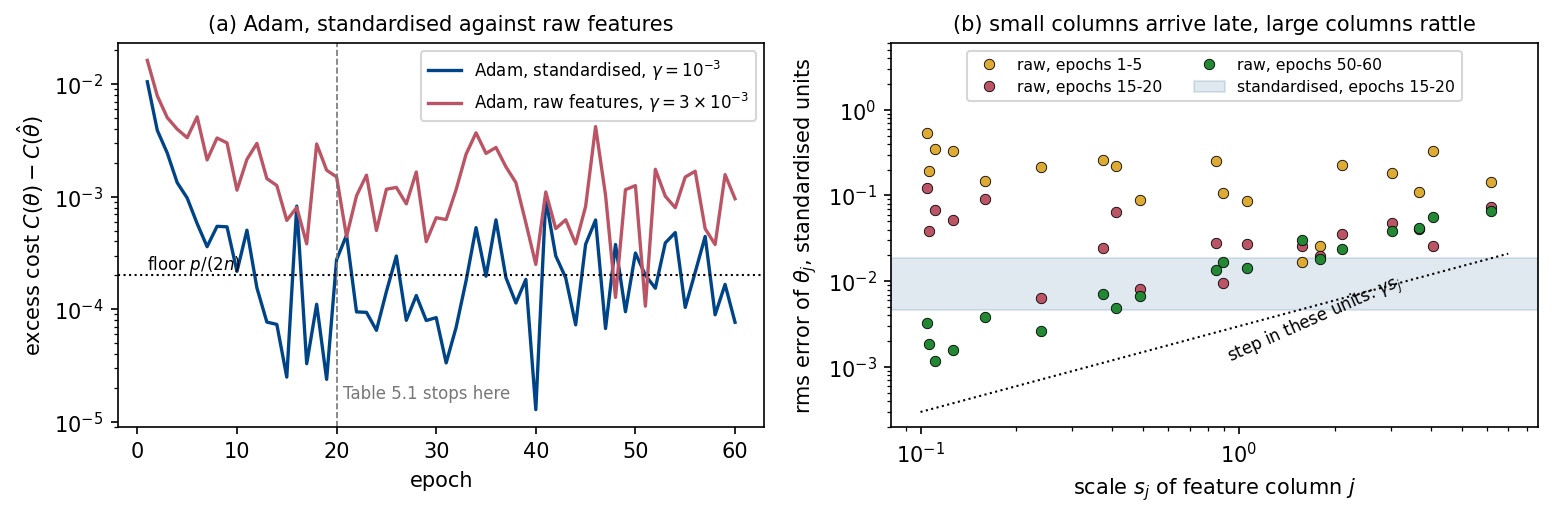

In [12]:
def adam_scales_experiment(n_epochs=60, M=32, seed=1):
    """The data of Section 5.9 (n = 50 000, p = 20, AR(1)-correlated
    standardised features) and the same data with every column multiplied
    by a factor s_j between 0.1 and 10.  Adam with minibatches of M at the
    learning rates of Table 5.1, followed parameter by parameter.
    Self-contained: same data seed and minibatch order as the book listing."""
    def sig(t):
        a = np.exp(-np.abs(t))
        return np.where(t >= 0, 1.0 / (1.0 + a), a / (1.0 + a))
    n, p, rho = 50_000, 20, 0.9
    rng = np.random.default_rng(2026)
    z = rng.normal(size=(n, p - 1))
    xc = np.empty_like(z); xc[:, 0] = z[:, 0]
    for j in range(1, p - 1):
        xc[:, j] = rho * xc[:, j - 1] + np.sqrt(1 - rho**2) * z[:, j]
    xc = (xc - xc.mean(0)) / xc.std(0)
    X = np.column_stack([np.ones(n), xc])
    theta_true = 0.5 * rng.normal(size=p)
    y = (rng.random(n) < sig(X @ theta_true)).astype(float)
    s = np.concatenate([[1.0], 10.0**rng.uniform(-1, 1, p - 1)])   # the "units"

    def cost(Xd, th):
        zz = Xd @ th
        return np.mean(np.logaddexp(0.0, zz) - y * zz)

    def hess(Xd, th):
        pr = sig(Xd @ th)
        return Xd.T @ ((pr * (1 - pr))[:, None] * Xd) / n

    def newton_solve(Xd):
        th = np.zeros(p)
        for _ in range(50):
            step = np.linalg.solve(hess(Xd, th), Xd.T @ (sig(Xd @ th) - y) / n)
            th -= step
            if np.linalg.norm(step) < 1e-12:
                break
        return th

    def adam(Xd, gamma, b1=0.9, b2=0.999, eps=1e-8):
        r = np.random.default_rng(seed)
        th, m, v, t, hist = np.zeros(p), 0.0, 0.0, 0, []
        for epoch in range(n_epochs):
            idx = r.permutation(n)
            for k in range(0, n, M):
                t += 1
                b = idx[k:k + M]
                g = Xd[b].T @ (sig(Xd[b] @ th) - y[b]) / len(b)
                m = b1 * m + (1 - b1) * g
                v = b2 * v + (1 - b2) * g * g
                th = th - gamma * (m / (1 - b1**t)) / (np.sqrt(v / (1 - b2**t)) + eps)
            hist.append(th.copy())
        return np.array(hist)

    out = {"s": s}
    for label, Xd, gamma in (("standardised", X, 0.001), ("raw", X * s, 0.003)):
        th_hat = newton_solve(Xd)
        H = hess(Xd, th_hat)
        d = np.sqrt(np.diag(H))
        hist = adam(Xd, gamma)
        out[label] = dict(
            theta_hat=th_hat, gamma=gamma, kappa=np.linalg.cond(H),
            kappa_jacobi=np.linalg.cond(H / np.outer(d, d)),   # D^-1/2 H D^-1/2
            excess=np.array([cost(Xd, th) for th in hist]) - cost(Xd, th_hat),
            rel_err=np.abs(hist - th_hat) / np.abs(th_hat),
            err_std=np.abs(hist - th_hat) * (s if label == "raw" else 1.0))
    return out


def figure_adam_scales(out, fname="week39_adam_scales.pdf"):
    s, raw, std = out["s"], out["raw"], out["standardised"]
    epochs = np.arange(1, len(raw["excess"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
    ax = axes[0]
    ax.semilogy(epochs, std["excess"], color=BLUE, lw=1.6, label=r"Adam, standardised, $\gamma=10^{-3}$")
    ax.semilogy(epochs, raw["excess"], color=RED, lw=1.6, label=r"Adam, raw features, $\gamma=3\times10^{-3}$")
    ax.axhline(20 / (2 * 50_000), color="k", ls=":", lw=1); ax.text(1, 2.25e-4, "floor $p/(2n)$", fontsize=8)
    ax.axvline(20, color=GREY, lw=0.8, ls="--"); ax.text(20.6, 1.6e-5, "Table 5.1 stops here", fontsize=8, color=GREY)
    ax.set_xlabel("epoch"); ax.set_ylabel(r"excess cost $C(\theta)-C(\hat\theta)$")
    ax.legend(fontsize=8, loc="upper right"); ax.set_title("(a) Adam, standardised against raw features", fontsize=10)
    ax = axes[1]
    rms = lambda E, a, b: np.sqrt((E[a - 1:b, 1:]**2).mean(0))
    for (a, b), col in (((1, 5), YELLOW), ((15, 20), RED), ((50, 60), GREEN)):
        ax.loglog(s[1:], rms(raw["err_std"], a, b), "o", color=col, ms=5, mec="k", mew=0.4,
                  label=f"raw, epochs {a}-{b}")
    lo = rms(std["err_std"], 15, 20)
    ax.axhspan(lo.min(), lo.max(), color=BLUE, alpha=0.12, label="standardised, epochs 15-20")
    g = np.array([0.1, 7.0]); ax.loglog(g, 3e-3 * g, ":", color="k", lw=1)
    ax.text(0.9, 1.15e-3, r"step in these units: $\gamma s_j$", fontsize=8, rotation=24)
    ax.set_xlabel(r"scale $s_j$ of feature column $j$")
    ax.set_ylabel("rms error of $\\theta_j$, standardised units")
    ax.set_ylim(2e-4, 6.0)
    ax.legend(fontsize=7.5, loc="upper center", ncol=2)
    ax.set_title("(b) small columns arrive late, large columns rattle", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname, bbox_inches="tight")
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150, bbox_inches="tight")
    plt.close(fig)


def print_adam_scales(out):
    s, raw, std = out["s"], out["raw"], out["standardised"]
    print(f"  kappa(H): standardised {std['kappa']:.0f}, raw {raw['kappa']:.2e}; after diagonal "
          f"preconditioning D^-1/2 H D^-1/2: {std['kappa_jacobi']:.1f} and {raw['kappa_jacobi']:.1f}")
    j, k = 1 + np.argmin(s[1:]), 1 + np.argmax(s[1:])
    print(f"  smallest column scale s = {s[j]:.3f}: theta_hat = {raw['theta_hat'][j]:.2f}; "
          f"largest s = {s[k]:.2f}: theta_hat = {raw['theta_hat'][k]:.4f}")
    for e in (1, 5, 10, 20, 40, 60):
        print(f"  epoch {e:2d}: excess raw {raw['excess'][e-1]:.1e}, standardised {std['excess'][e-1]:.1e}; "
              f"relative error of the small-scale parameter {raw['rel_err'][e-1, j]:.2f}, "
              f"of the large-scale one {raw['rel_err'][e-1, k]:.2f}")
    rms = lambda E, a, b: np.sqrt((E[a - 1:b, 1:]**2).mean(0))
    small, large = s[1:] < 0.3, s[1:] > 3.0
    for a, b in ((1, 5), (15, 20), (50, 60)):
        r = rms(raw["err_std"], a, b); q = rms(std["err_std"], a, b)
        print(f"  rms error in standardised units, epochs {a}-{b}: raw, columns with s<0.3: {r[small].mean():.3f}, "
              f"s>3: {r[large].mean():.3f}; standardised run, all columns: {q.mean():.3f}")
    print(f"  mean excess, epochs 15-20: raw {raw['excess'][14:20].mean():.1e}, standardised {std['excess'][14:20].mean():.1e}; "
          f"epochs 40-60: raw {raw['excess'][39:].mean():.1e}, standardised {std['excess'][39:].mean():.1e}")


res = adam_scales_experiment()
figure_adam_scales(res)
print_adam_scales(res)
Image("week39_adam_scales.png", width=900)

The condition number after diagonal preconditioning is $189$ for the raw *and*
for the standardised data — no better than the $173$ we started from, so on
standardised data the adaptive methods have nothing to remove. On the raw
data they remove a factor $4.4\times10^{4}/189$ that plain SGD, with its single
$\gamma$ set by the largest column, has to live with.

What Adam does not remove is the *distance to go*. Its update has length
$\lesssim\gamma$ in every parameter, whatever its unit (Eq. 4.56), but the
parameters now live on scales from $\hat\theta'_j=7.2$ (the column with
$s_j=0.10$) to $0.08$ ($s_j=6.2$); measured in standardised units the step is
$\gamma s_j$, the dotted line of panel (b). The parameters of the small columns
arrive late — the largest one is 87 %, 54 %, 32 %, 13 % and 2 % short after 1,
5, 10, 20 and 40 epochs — while those of the large columns rattle, because for
them $\gamma=0.003$ is eighteen times the step of the standardised run. One
$\gamma$ cannot be right for both, and the raw run stays at $10^{-3}$ while the
standardised one sits at the floor. Standardising puts all parameters on the
same scale, so that one step length fits all; in a neural network the inner
layers cannot be standardised by hand, and that is where Adam earns its keep.

## Part 3: logistic regression as a single neuron (Section 5.8.1)

Drawn as a diagram, logistic regression is a single artificial neuron: the
features enter on the left, every edge carries a parameter, the intercept is
the weight of an input fixed at one, $\Sigma$ forms the linear predictor $z$,
and $\sigma$ turns it into the probability. With the step function in place of
$\sigma$ this is Rosenblatt's perceptron.

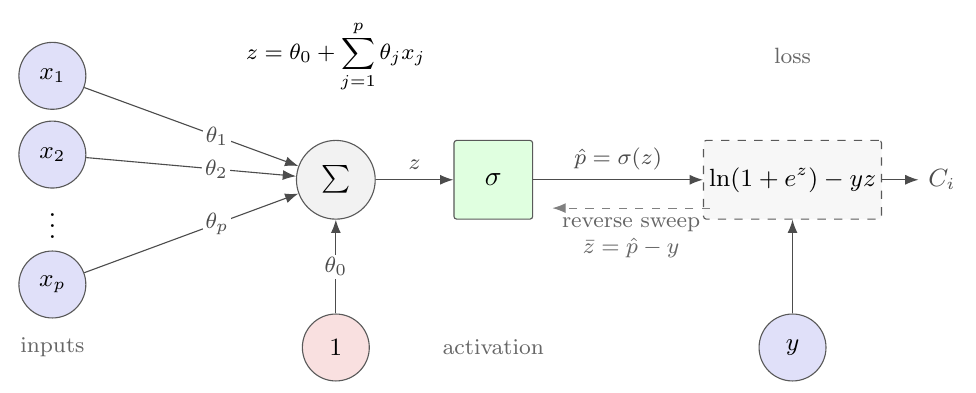

In [11]:
Image("../BookFigures/chapter05_logistic_regression/5-neuron.png", width=700)

The cost of one observation depends on the parameters only through $z$, so
by the chain rule through the two nodes, Eq. (5.36),

$$
\frac{\partial C_i}{\partial\theta_j}=(\hat p_i-y_i)\,x_{ij},
\qquad
\theta_j\leftarrow\theta_j-\gamma(\hat p_i-y_i)x_{ij}\quad\text{(the delta rule, Eq. 5.37)}.
$$

This is Rosenblatt's perceptron rule with a differentiable output, and it is
SGD with $M=1$ on the cross entropy. Below, the delta rule run on the CHD data
— one observation at a time, a decaying learning rate — ends where Newton's
method ended above.

In [13]:
age, group, chd = load_chd()
Xn, mu, sd = chd_design(age)                 # the neuron's inputs: 1 and the standardised age
theta_newton = theta                         # Newton's solution from Part 2
rng = np.random.default_rng(2026)
w, t = np.zeros(2), 0                        # bias and weight
for epoch in range(200):
    for i in rng.permutation(len(chd)):
        t += 1
        p_hat = 1.0 / (1.0 + np.exp(-Xn[i] @ w))           # the neuron's output
        w -= 0.5 * 200 / (t + 200) * (p_hat - chd[i]) * Xn[i]   # the delta rule, Eq. (5.37)
print("delta rule, 200 epochs:", w)
print("Newton-Raphson        :", theta_newton)

delta rule, 200 epochs: [-0.3664  1.204 ]
Newton-Raphson        : [-0.3665  1.2034]


With the step function in place of the sigmoid the node has derivative zero
almost everywhere and no gradient reaches the parameters; with the sigmoid the
rule is gradient descent on a convex cost. Read backwards, the same diagram is
reverse-mode automatic differentiation (Section 5.8.2) — we pick that up in
week 40, where the neuron appears in layers and the sweep is called
backpropagation.

## Summary

* **SGD**: unbiased minibatch gradient, an epoch costs one full step, decay
  $\gamma$ or rattle (Eqs. 4.32–4.40).
* **Logistic regression**: linear log-odds; Bernoulli likelihood gives the
  cross entropy; gradient $\boldsymbol{X}^T(\boldsymbol{p}-\boldsymbol{y})$,
  Hessian $\boldsymbol{X}^T\boldsymbol{W}\boldsymbol{X}$, convex; Newton is
  IRLS; a penalty is necessary on separable data (Sections 5.1–5.7).
* **Standardise, then choose the optimiser**: the adaptive methods remove the
  column scales from the curvature ($\kappa$: $4.4\times10^{4}\to189$), not from
  the distance each parameter has to travel, and never the correlation
  (Section 5.9).
* **The neuron**: the perceptron with a sigmoid; its gradient is the delta
  rule, Eq. (5.37) (Section 5.8.1).

Tuesday: your questions, then how to write the report. Exercises due
**Friday September 25 at midnight**.